# Hackathon

In [1]:
import torch

# Check if CUDA (GPU support) is available
gpu_available = torch.cuda.is_available()

print(f"GPU Available: {gpu_available}")
if gpu_available:
    print(f"Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Current Device Index: {torch.cuda.current_device()}")

GPU Available: True
Device Name: NVIDIA L40S
Current Device Index: 0


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, Dataset
import random
from copy import deepcopy
import pandas as pd
from scipy.stats import spearmanr
import argparse
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

## 1. collect training data

Upload `sequence.fasta`, `train.csv`, and `test.csv` to the current runtime:

1. click the folder icon on the left

2. click the upload icon and upload the files to the current directory

In [3]:
with open('sequence.fasta', 'r') as f:
  data = f.readlines()

sequence_wt = data[1].strip()
sequence_wt

'MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLREKMRRRLESGDKWFSLEFFPPRTAEGAVNLISRFDRMAAGGPLYIDVTWHPAGDPGSDKETSSMMIASTAVNYCGLETILHMTCCRQRLEEITGHLHKAKQLGLKNIMALRGDPIGDQWEEEEGGFNYAVDLVKHIRSEFGDYFDICVAGYPKGHPEAGSFEADLKHLKEKVSAGADFIITQLFFEADTFFRFVKACTDMGITCPIVPGIFPIQGYHSLRQLVKLSKLEVPQEIKDVIEPIKDNDAAIRNYGIELAVSLCQELLASGLVPGLHFYTLNREMATTEVLKRLGMWTEDPRRPLPWALSAHPKRREEDVRPIFWASRPKSYIYRTQEWDEFPNGRWGNSSSPAFGELKDYYLFYLKSKSPKEELLKMWGEELTSEESVFEVFVLYLSGEPNRNGHKVTCLPWNDEPLAAETSLLKEELLRVNRQGILTINSQPNINGKPSSDPIVGWGPSGGYVFQKAYLEFFTSRETAEALLQVLKKYELRVNYHLVNVKGENITNAPELQPNAVTWGIFPGREIIQPTVVDPVSFMFWKDEAFALWIERWGKLYEEESPSRTIIQYIHDNYFLVNLVDNDFPLDNCLWQVVEDTLELLNRPTQNARETEAP'

In [4]:
len(sequence_wt)

656

In [5]:
def get_mutated_sequence(mut, sequence_wt):
  wt, pos, mt = mut[0], int(mut[1:-1]), mut[-1]

  sequence = deepcopy(sequence_wt)

  return sequence[:pos]+mt+sequence[pos+1:]

In [6]:
df_train = pd.read_csv('train.csv')
df_train['sequence'] = df_train.mutant.apply(lambda x: get_mutated_sequence(x, sequence_wt))
df_train

,mutant,DMS_score,sequence
0,M0Y,0.2730,YVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1,M0W,0.2857,WVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
2,M0V,0.2153,VVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
3,M0T,0.3122,TVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
4,M0S,0.2180,SVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
...,...,...,...
1135,P347D,0.3876,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1136,P347C,0.1837,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1137,P347A,0.4611,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1138,P347M,0.2412,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...


In [7]:
df_test = pd.read_csv('test.csv')
df_test['sequence'] = df_test.mutant.apply(lambda x: get_mutated_sequence(x, sequence_wt))
df_test


,mutant,sequence
0,V1D,MDNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1,V1Y,MYNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
2,V1C,MCNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
3,V1A,MANEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
4,V1E,MENEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
...,...,...
11319,P655S,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
11320,P655T,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
11321,P655V,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
11322,P655A,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...


In [8]:
# TODO: integrate the query data that you acquired each round into df_train
query_data = pd.read_csv('query1_result')
df_train = pd.concat([df_train, query_data], ignore_index=True)
query_data = pd.read_csv('query2_result')
df_train = pd.concat([df_train, query_data], ignore_index=True)
query_data = pd.read_csv('query3_result')
df_train = pd.concat([df_train, query_data], ignore_index=True)
df_train


,mutant,DMS_score,sequence
0,M0Y,0.273000,YVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1,M0W,0.285700,WVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
2,M0V,0.215300,VVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
3,M0T,0.312200,TVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
4,M0S,0.218000,SVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
...,...,...,...
1435,I608L,0.937841,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1436,Q609S,0.793713,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1437,Q609N,0.899687,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1438,D613E,0.946005,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...


In [9]:
# !pip install seaborn

# 2. MODEL TRAINING 
## ESM2 baseline pipeline (final)
Run cells in order:
1. Build ESM2 embeddings for `df_train` and `df_test`
2. Compare Ridge vs MLP with 5-fold CV (Spearman + MSE)
3. Fit the selected model on all train embeddings and export predictions

In [10]:
# resolving PACE import error issues 

import sys
import torch.nn as nn
from unittest.mock import MagicMock

# 1. Setup Apex mocks as before
mock_apex = MagicMock()
mock_apex.__name__ = "apex"
mock_apex.normalization = MagicMock()
mock_apex.normalization.fused_layer_norm = MagicMock()

# 2. Map FusedLayerNorm DIRECTLY to nn.LayerNorm (no wrapper)
mock_apex.normalization.fused_layer_norm.FusedLayerNorm = nn.LayerNorm

sys.modules["apex"] = mock_apex
sys.modules["apex.normalization"] = mock_apex.normalization
sys.modules["apex.normalization.fused_layer_norm"] = mock_apex.normalization.fused_layer_norm

# 3. Clean and reload ESM
if "esm" in sys.modules:
    for mod in list(sys.modules.keys()):
        if mod.startswith("esm"):
            del sys.modules[mod]

import esm

# 4. Map the internal ESM LayerNorm classes directly to the standard one
esm.model.esm2.ESM1bLayerNorm = nn.LayerNorm
esm.modules.ESM1bLayerNorm = nn.LayerNorm

print("Bypass updated: Model architecture now matches standard weight keys.")

Bypass updated: Model architecture now matches standard weight keys.


In [11]:
import numpy as np
import torch
import esm
from tqdm import tqdm  # Progress bar library

# --------------------
# Config
# --------------------
random_seed = 42
torch.manual_seed(random_seed)
np.random.seed(random_seed)

embedding_batch_size = 8  
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# --------------------
# Load ESM2 model
# --------------------
esm_model, esm_alphabet = esm.pretrained.esm2_t33_650M_UR50D()
esm_model = esm_model.to(device)
esm_model.eval()
batch_converter = esm_alphabet.get_batch_converter()

# Fix for the AttributeError: ESM2 does not have max_positions
max_tokens = 1024 
repr_layer = esm_model.num_layers

def embed_sequences_esm2(sequence_list, batch_size=8, desc="Embedding"):
    embedded_batches = []
    
    # Calculate total steps for the progress bar
    total_steps = (len(sequence_list) + batch_size - 1) // batch_size

    with torch.no_grad():
        # Wrap the loop in tqdm to show progress
        for start_index in tqdm(range(0, len(sequence_list), batch_size), total=total_steps, desc=desc):
            batch_sequences = sequence_list[start_index:start_index + batch_size]
            batch_data = [
                (f"seq_{start_index + idx}", seq[: max_tokens - 2])
                for idx, seq in enumerate(batch_sequences)
            ]
            _, _, batch_tokens = batch_converter(batch_data)
            batch_tokens = batch_tokens.to(device)

            outputs = esm_model(batch_tokens, repr_layers=[repr_layer], return_contacts=False)
            token_representations = outputs["representations"][repr_layer]

            for sequence_index, sequence in enumerate(batch_sequences):
                effective_length = min(len(sequence), max_tokens - 2)
                sequence_embedding = token_representations[sequence_index, 1:effective_length + 1].mean(dim=0)
                embedded_batches.append(sequence_embedding.detach().cpu().numpy())

    return np.vstack(embedded_batches)

# --------------------
# Build embeddings with progress bars
# --------------------
print("Generating Train Embeddings...")
X_train_embeddings = embed_sequences_esm2(df_train["sequence"].tolist(), batch_size=embedding_batch_size, desc="Train Set")

print("\nGenerating Test Embeddings...")
X_test_embeddings = embed_sequences_esm2(df_test["sequence"].tolist(), batch_size=embedding_batch_size, desc="Test Set")

y_train_scores = df_train["DMS_score"].values.astype(np.float32)

print("\n" + "="*30)
print("Train embeddings shape:", X_train_embeddings.shape)
print("Test embeddings shape:", X_test_embeddings.shape)
print("Embeddings are ready for model selection and final fit.")

Using device: cuda
Generating Train Embeddings...


Train Set: 100%|██████████| 180/180 [00:47<00:00,  3.78it/s]



Generating Test Embeddings...


Test Set: 100%|██████████| 1416/1416 [06:09<00:00,  3.83it/s]


Train embeddings shape: (1440, 1280)
Test embeddings shape: (11324, 1280)
Embeddings are ready for model selection and final fit.


In [12]:
#adding evolution score as feature 
import torch.nn.functional as F

def evolutionary_score(seq_wt, mask_pos, mut_aa):
    wt_aa = seq_wt[mask_pos]
    
    # In ESM, the mask token is accessed via the alphabet
    mask_token = esm_alphabet.all_toks[esm_alphabet.mask_idx]
    seq_masked = seq_wt[:mask_pos] + mask_token + seq_wt[mask_pos+1:]

    # Prepare data for ESM (expects list of tuples)
    batch_data = [("temp", seq_masked)]
    labels, strs, tokens = batch_converter(batch_data)
    tokens = tokens.to(device)

    with torch.no_grad():
        # Get logits from esm_model
        results = esm_model(tokens, repr_layers=[esm_model.num_layers])
        logits = results["logits"]  # [1, L, vocab_size]

    # Convert to log-probabilities
    log_probs = F.log_softmax(logits, dim=-1)

    # Get token indices from esm_alphabet
    wt_id = esm_alphabet.get_idx(wt_aa)
    mut_id = esm_alphabet.get_idx(mut_aa)

    # ESM tokens usually have a BOS token at index 0, 
    # so position i in the string is at index i+1 in the tokens
    pos = mask_pos + 1

    score = (log_probs[0, pos, mut_id] - log_probs[0, pos, wt_id]).item()

    return score

In [13]:
def get_scores_for_df(df, desc="Calculating Evo Scores"):
    scores = []
    # We use tqdm to track progress
    for _, row in tqdm(df.iterrows(), total=len(df), desc=desc):
        mut = row['mutant']
        # Parse mutant string (e.g., 'M0Y' -> wt='M', pos=0, mt='Y')
        pos = int(mut[1:-1])
        mt_aa = mut[-1]
        
        score = evolutionary_score(sequence_wt, pos, mt_aa)
        scores.append(score)
    return np.array(scores).reshape(-1, 1)

print("Processing Train Scores...")
train_evo_features = get_scores_for_df(df_train)

print("Processing Test Scores...")
test_evo_features = get_scores_for_df(df_test)

Processing Train Scores...


Calculating Evo Scores: 100%|██████████| 1440/1440 [00:37<00:00, 38.47it/s]


Processing Test Scores...


Calculating Evo Scores: 100%|██████████| 11324/11324 [04:54<00:00, 38.49it/s]


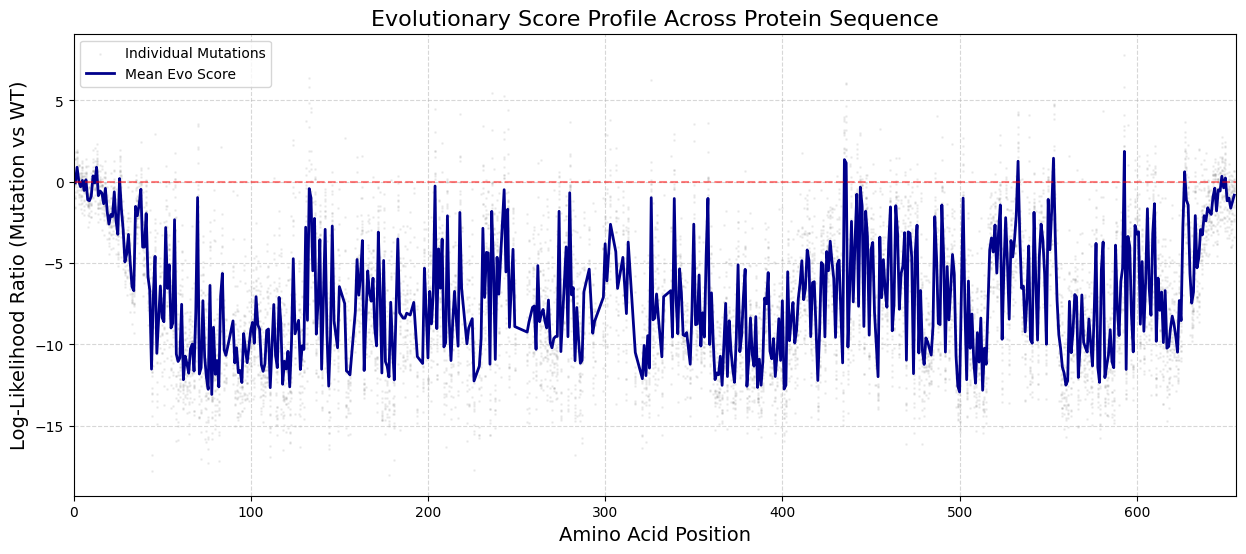

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Prepare the data
# Extract positions from df_test (matching the order of test_evo_features)
positions = [int(''.join(filter(str.isdigit, m))) for m in df_test['mutant']]

# Create a temporary DataFrame for plotting
df_plot = pd.DataFrame({
    'position': positions,
    'evo_score': test_evo_features.flatten()  # From Cell [39]
})

# 2. Aggregate: Calculate mean evolutionary score per position
# This creates the "curve" across the sequence
pos_means = df_plot.groupby('position')['evo_score'].mean().reset_index()

# 3. Setup the Plot
plt.figure(figsize=(15, 6))

# Plot the individual mutation points (optional, adds context)
plt.scatter(df_plot['position'], df_plot['evo_score'], alpha=0.1, s=1, color='gray', label='Individual Mutations')

# Plot the trend line (The Evo Score Curve)
sns.lineplot(data=pos_means, x='position', y='evo_score', color='darkblue', linewidth=2, label='Mean Evo Score')

# 4. Formatting
plt.title('Evolutionary Score Profile Across Protein Sequence', fontsize=16)
plt.xlabel('Amino Acid Position', fontsize=14)
plt.ylabel('Log-Likelihood Ratio (Mutation vs WT)', fontsize=14)
plt.xlim(0, len(sequence_wt))
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Zero line: scores below this are "worse" than WT
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.show()

In [15]:
# Concatenate along axis 1 (columns)
X_train_combined = np.hstack([X_train_embeddings, train_evo_features])
X_test_combined = np.hstack([X_test_embeddings, test_evo_features])

print(f"New feature shape: {X_train_combined.shape}") 

New feature shape: (1440, 1281)


In [16]:
# !pip install blosum

In [17]:
import blosum as bl
matrix = bl.BLOSUM(62)

def get_blosum_feature(df):
    scores = []
    for mut in df['mutant']:
        wt_aa = mut[0]
        mt_aa = mut[-1]
        # Look up the score; if not found (e.g., non-standard AA), default to 0
        try:
            score = matrix[wt_aa][mt_aa]
        except:
            score = 0
        scores.append(score)
    
    # Reshape to (N, 1) to match your combined features
    return np.array(scores).reshape(-1, 1)

In [18]:
print("Generating BLOSUM features...")
train_blosum = get_blosum_feature(df_train)
test_blosum = get_blosum_feature(df_test)

# Stack them onto the current 1281-dimensional vectors
X_train_combined = np.hstack([X_train_combined, train_blosum])
X_test_combined = np.hstack([X_test_combined, test_blosum])

print(f"New feature shape: {X_train_combined.shape}") 
# This should now be (1440, 1282)

Generating BLOSUM features...
New feature shape: (1440, 1282)


In [19]:
from Bio.SeqUtils import ProtParamData
import numpy as np

# 1. Hydrophobicity Scale (Kyte & Doolittle)
kd_scale = ProtParamData.kd

# 2. Molecular Weights for individual amino acids
aa_weights = {
    'A': 89.09, 'R': 174.20, 'N': 132.12, 'D': 133.10, 'C': 121.16,
    'Q': 146.15, 'E': 147.13, 'G': 75.07, 'H': 155.16, 'I': 131.18,
    'L': 131.18, 'K': 146.19, 'M': 149.21, 'F': 165.19, 'P': 115.13,
    'S': 105.09, 'T': 119.12, 'W': 204.23, 'Y': 181.19, 'V': 117.15
}

def get_physchem_features(df):
    features = []
    for mut in df['mutant']:
        wt_aa, mt_aa = mut[0], mut[-1]
        
        # Calculate Deltas (Mutant - Wildtype)
        # Weight Delta: Positive means the mutation added bulk
        mw_delta = aa_weights.get(mt_aa, 0) - aa_weights.get(wt_aa, 0)
        
        # Hydrophobicity Delta: Positive means the mutation is more hydrophobic
        hydro_delta = kd_scale.get(mt_aa, 0) - kd_scale.get(wt_aa, 0)
        
        features.append([mw_delta, hydro_delta])
        
    return np.array(features)

# Generate features
print("Extracting Physicochemical Deltas...")
train_physchem = get_physchem_features(df_train)
test_physchem = get_physchem_features(df_test)

# Stack them onto the existing vectors (1282 -> 1284 dimensions)
X_train_combined = np.hstack([X_train_combined, train_physchem])
X_test_combined = np.hstack([X_test_combined, test_physchem])

print(f"Final feature shape: {X_train_combined.shape}")

Extracting Physicochemical Deltas...
Final feature shape: (1440, 1284)


In [20]:
def get_positional_features(df):
    pos_features = []
    seq_len = 656 
    
    for mut in df['mutant']:
        # 1. Normalized position
        pos = int(mut[1:-1])
        rel_pos = pos / seq_len
        
        # 2. WT AA as an index (0-19)
        wt_aa = mut[0]
        wt_idx = esm_alphabet.get_idx(wt_aa)
        
        pos_features.append([rel_pos, wt_idx])
    return np.array(pos_features)

# Generate and stack
train_pos = get_positional_features(df_train)
test_pos = get_positional_features(df_test)

X_train_combined = np.hstack([X_train_combined, train_pos])
X_test_combined = np.hstack([X_test_combined, test_pos])

print(f"Final feature shape: {X_train_combined.shape}")

Final feature shape: (1440, 1286)


### Model selection on ESM embeddings: Ridge vs MLP (5-fold CV)
Run this after the ESM embedding cell above. It compares both models using Spearman and MSE.

In [21]:
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr
import numpy as np

if "X_train_embeddings" not in globals() or "y_train_scores" not in globals():
    raise RuntimeError("Please run the ESM embedding cell first so X_train_embeddings and y_train_scores are available.")

X = X_train_combined
y = y_train_scores

kf = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_spearman_scores, ridge_mse_scores = [], []
mlp_spearman_scores, mlp_mse_scores = [], []

for fold_idx, (train_index, val_index) in enumerate(kf.split(X), start=1):
    X_train_fold, X_val_fold = X[train_index], X[val_index]
    y_train_fold, y_val_fold = y[train_index], y[val_index]

    ridge_model = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=np.logspace(-3, 3, 13))
    )
    ridge_model.fit(X_train_fold, y_train_fold)
    ridge_pred = ridge_model.predict(X_val_fold)
    ridge_mse = mean_squared_error(y_val_fold, ridge_pred)
    ridge_spearman = spearmanr(y_val_fold, ridge_pred).correlation
    ridge_mse_scores.append(ridge_mse)
    ridge_spearman_scores.append(ridge_spearman)

    mlp_model = make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=(512, 256),
            activation="relu",
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=15,
            random_state=42
        )
    )
    mlp_model.fit(X_train_fold, y_train_fold)
    mlp_pred = mlp_model.predict(X_val_fold)
    mlp_mse = mean_squared_error(y_val_fold, mlp_pred)
    mlp_spearman = spearmanr(y_val_fold, mlp_pred).correlation
    mlp_mse_scores.append(mlp_mse)
    mlp_spearman_scores.append(mlp_spearman)

    print(
        f"Fold {fold_idx}: "
        f"Ridge rho={ridge_spearman:.4f}, mse={ridge_mse:.5f} | "
        f"MLP rho={mlp_spearman:.4f}, mse={mlp_mse:.5f}"
    )

ridge_rho_mean = float(np.nanmean(ridge_spearman_scores))
mlp_rho_mean = float(np.nanmean(mlp_spearman_scores))
ridge_mse_mean = float(np.mean(ridge_mse_scores))
mlp_mse_mean = float(np.mean(mlp_mse_scores))

print("\n===== 10-fold CV Summary =====")
print(f"Ridge: mean Spearman={ridge_rho_mean:.4f}, mean MSE={ridge_mse_mean:.5f}")
print(f"MLP  : mean Spearman={mlp_rho_mean:.4f}, mean MSE={mlp_mse_mean:.5f}")

if mlp_rho_mean > ridge_rho_mean:
    print("Winner by Spearman: MLP")
else:
    print("Winner by Spearman: Ridge")

Fold 1: Ridge rho=0.6679, mse=0.03739 | MLP rho=0.5362, mse=0.07202
Fold 2: Ridge rho=0.7069, mse=0.03556 | MLP rho=0.6237, mse=0.05698
Fold 3: Ridge rho=0.6780, mse=0.03681 | MLP rho=0.5431, mse=0.07137
Fold 4: Ridge rho=0.7069, mse=0.03190 | MLP rho=0.5606, mse=0.08483
Fold 5: Ridge rho=0.7441, mse=0.03786 | MLP rho=0.5512, mse=0.08760

===== 10-fold CV Summary =====
Ridge: mean Spearman=0.7008, mean MSE=0.03590
MLP  : mean Spearman=0.5630, mean MSE=0.07456
Winner by Spearman: Ridge


### Ridge final fit + export predictions
This cell uses the CV winner (Ridge or MLP), fits on all training embeddings, and saves `test_predictions.csv` + `kaggle_ridge_predictions.csv`.

In [22]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

# Updated check to ensure the combined features are ready
if "X_train_combined" not in globals() or "X_test_combined" not in globals() or "y_train_scores" not in globals():
    raise RuntimeError("Please run the cells that generate X_train_combined and X_test_combined first.")

# Optional override: set force_model = "Ridge" or "MLP" before running this cell
force_model = globals().get("force_model", None)

if force_model in ["Ridge", "MLP"]:
    selected_model_name = force_model
elif "ridge_rho_mean" in globals() and "mlp_rho_mean" in globals():
    selected_model_name = "MLP" if mlp_rho_mean > ridge_rho_mean else "Ridge"
else:
    selected_model_name = "Ridge"

if selected_model_name == "Ridge":
    final_model = make_pipeline(
        StandardScaler(),
        RidgeCV(alphas=np.logspace(-3, 3, 13))
    )
    # Fit and predict using combined features (1281 dimensions)
    final_model.fit(X_train_combined, y_train_scores)
    final_test_predictions = final_model.predict(X_test_combined).astype(np.float32)
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    class FinalTorchMLP(nn.Module):
        def __init__(self, input_dim):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, 512),
                nn.BatchNorm1d(512),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(512, 256),
                nn.BatchNorm1d(256),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(256, 1)
            )

        def forward(self, features):
            return self.net(features).squeeze(-1)

    # Scaling logic updated for combined features
    x_mean = X_train_combined.mean(axis=0, keepdims=True)
    x_std = X_train_combined.std(axis=0, keepdims=True)
    x_std[x_std == 0] = 1.0

    X_train_scaled = (X_train_combined - x_mean) / x_std
    X_test_scaled = (X_test_combined - x_mean) / x_std

    X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_scores, dtype=torch.float32)
    X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

    train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

    # input_dim will now be 1281
    model = FinalTorchMLP(input_dim=X_train_combined.shape[1]).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    model.train()
    for epoch in range(60):
        epoch_losses = []
        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            pred = model(batch_x)
            loss = criterion(pred, batch_y)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch + 1:02d} | Train MSE: {np.mean(epoch_losses):.6f}")

    model.eval()
    with torch.no_grad():
        final_test_predictions = model(X_test_tensor.to(device)).cpu().numpy().astype(np.float32)

print(f"Selected final model: {selected_model_name}")

Selected final model: Ridge


In [23]:
# !pip install xgboost
import xgboost as xgb

In [24]:
#use XGBoost for training

from sklearn.model_selection import KFold
from scipy.stats import spearmanr
from sklearn.metrics import mean_squared_error

X = X_train_combined
y = y_train_scores

kf = KFold(n_splits=5, shuffle=True, random_state=42)
xgb_spearman_scores = []

for fold_idx, (train_index, val_index) in enumerate(kf.split(X), start=1):
    X_train_fold, X_val_fold = X[train_index], X[val_index]
    y_train_fold, y_val_fold = y[train_index], y[val_index]

    # XGBoost Regressor
    # We use early stopping to prevent overfitting
    xgb_model = xgb.XGBRegressor(
        n_estimators=1000,
        max_depth=8,           # Depth of 6 is usually a good starting point
        learning_rate=0.01,    # Low learning rate for better generalization
        subsample=0.8,
        colsample_bytree=0.8, # can try 0.5 later
        random_state=42,
        objective='rank:pairwise', 
        tree_method='gpu_hist',    # Fast histogram-based method
        predictor='gpu_predictor'
    )

    xgb_model.fit(
        X_train_fold, y_train_fold,
        eval_set=[(X_val_fold, y_val_fold)],
        verbose=False
    )

    preds = xgb_model.predict(X_val_fold)
    rho = spearmanr(y_val_fold, preds).correlation
    xgb_spearman_scores.append(rho)
    
    print(f"Fold {fold_idx}: XGBoost Spearman rho = {rho:.4f}")

print(f"\nAverage XGBoost Spearman: {np.mean(xgb_spearman_scores):.4f}")

Fold 1: XGBoost Spearman rho = 0.6817
Fold 2: XGBoost Spearman rho = 0.7399
Fold 3: XGBoost Spearman rho = 0.6585
Fold 4: XGBoost Spearman rho = 0.7104
Fold 5: XGBoost Spearman rho = 0.7499

Average XGBoost Spearman: 0.7081


In [25]:
# Train on ALL data using XGBoost 1.7.5 GPU parameters
final_xgb = xgb.XGBRegressor(
    n_estimators=500,        # Number of trees from your best CV results
    max_depth=8,             # I recommend 8 based on your 0.7108 score
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.5,    # Helps prioritize your engineered features
    random_state=42,
    objective='rank:pairwise', 
    # Proper parameters for XGBoost 1.7.5 + H200 GPU:
    tree_method='gpu_hist',
    predictor='gpu_predictor'
)

print("Starting final training on H200 GPU...")
final_xgb.fit(X_train_combined, y_train_scores)

# Predict on test set
print("Generating predictions...")
xgb_test_preds = final_xgb.predict(X_test_combined)

# Save for Kaggle
kaggle_xgb = pd.DataFrame({
    "id": np.arange(len(xgb_test_preds)),
    "DMS_score": xgb_test_preds
})
kaggle_xgb.to_csv("kaggle_xgb_predictions.csv", index=False)
print("XGBoost predictions saved to kaggle_xgb_predictions.csv")

Starting final training on H200 GPU...
Generating predictions...
XGBoost predictions saved to kaggle_xgb_predictions.csv


In [26]:
from sklearn.preprocessing import minmax_scale

# 1. Scale both predictions to [0, 1] so the weights 0.7 and 0.3 are balanced
ridge_scaled = minmax_scale(final_test_predictions)
xgb_scaled = minmax_scale(xgb_test_preds)

# 2. Apply the weighted average
ensemble_preds = (0.7 * xgb_scaled) + (0.3 * ridge_scaled)

print("Ensemble completed.")

Ensemble completed.


In [27]:
from scipy.stats import spearmanr
from sklearn.preprocessing import minmax_scale

# 1. Get Out-of-Fold (OOF) predictions or validation predictions
# Assuming you saved your validation predictions from the last fold
# or re-running a quick validation split:

# Scale the validation predictions from your Ridge and XGBoost models
val_ridge_scaled = minmax_scale(ridge_pred) # from your Ridge CV loop
val_xgb_scaled = minmax_scale(preds)        # from your XGBoost CV loop

# 2. Create the Ensemble Validation Prediction
val_ensemble = (0.7 * val_xgb_scaled) + (0.3 * val_ridge_scaled)

# 3. Calculate Spearman for all three
rho_ridge = spearmanr(y_val_fold, ridge_pred).correlation
rho_xgb = spearmanr(y_val_fold, preds).correlation
rho_ensemble = spearmanr(y_val_fold, val_ensemble).correlation

print(f"--- Validation Results (Final Fold) ---")
print(f"Ridge Spearman:    {rho_ridge:.4f}")
print(f"XGBoost Spearman:  {rho_xgb:.4f}")
print(f"Ensemble Spearman: {rho_ensemble:.4f}")

if rho_ensemble > max(rho_ridge, rho_xgb):
    print("\n✅ Success: The ensemble improved the Spearman score!")
else:
    print("\n❌ The ensemble did not improve the score. Try adjusting the weights (e.g., 0.8/0.2).")

--- Validation Results (Final Fold) ---
Ridge Spearman:    0.7441
XGBoost Spearman:  0.7499
Ensemble Spearman: 0.7622

✅ Success: The ensemble improved the Spearman score!


In [28]:
#generate test_prediction.tsv

from sklearn.preprocessing import minmax_scale
import pandas as pd
import numpy as np
from tqdm import tqdm

# 1. Generate final Ridge predictions (if not already in memory)
print("Generating final Ridge predictions...")
ridge_test_preds = ridge_model.predict(X_test_combined).astype(np.float32)

# 2. Generate final XGBoost predictions (if not already in memory)
print("Generating final XGBoost predictions...")
xgb_test_preds = final_xgb.predict(X_test_combined)

# 3. Scale both to [0, 1] to ensure equal footing for weighting
ridge_scaled = minmax_scale(ridge_test_preds)
xgb_scaled = minmax_scale(xgb_test_preds)

# 4. Create Weighted Ensemble (0.7 XGBoost + 0.3 Ridge)
ensemble_preds = (0.7 * xgb_scaled) + (0.3 * ridge_scaled)

# 5. Save to test_predictions.csv
df_test["DMS_score_predicted"] = ensemble_preds
df_test[["mutant", "DMS_score_predicted"]].to_csv("test_predictions.csv", index=False)

# 6. Create Kaggle-specific submission file
kaggle_submission = pd.DataFrame({
    "id": np.arange(len(ensemble_preds)),
    "DMS_score": ensemble_preds
})
kaggle_submission.to_csv("kaggle_ensemble_submission.csv", index=False)

print("✅ Success: Created 'test_predictions.csv' and 'kaggle_ensemble_submission.csv'")

Generating final Ridge predictions...
Generating final XGBoost predictions...
✅ Success: Created 'test_predictions.csv' and 'kaggle_ensemble_submission.csv'
